In [53]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

In [ ]:
#start - how is flare input? - start and end times
    #find from both stix and goes - do times need to be processed in any way? how should they be input?
    #convert to df?
    #time correct stix
        #earth_tdel = stix_ts.meta.metas[0]["EAR_TDEL"]
        # how to apply this shift to time objects? how to update timeseries?
    #plot stix and goes on same axes - ax.twinx()
    #find and shade attenuator regions
        # rcr != 0 --> axvspan
    #mark peak (shifted)
    #return plot

#possible extensions:
    #accept multiple formats for tstart, tend (i.e. can convert btwn string and
    #time obj. as needed
    #if case for flare not seen by goes - incorporating list (needed for peak
    #val. anyway?)
        #if flares[*corresponding index for given times*][visible from Earth]=
        #False - print(this flare could not be seen by Goes)
        #set some condition to false - don't carry out goes part
    #options - added option to provide peak val, also
    # shade_attenuator=True, mark_peak=True
    #use_stix_flare_list=False

#FIXES:


In [109]:
def plot_flare(tstart, tend, tpeak=None, shade_attenuator=True):
    #getting STIX data
    stix_query = Fido.search(a.Time(tstart, tend), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

    stix_files = Fido.fetch(stix_query)
    stix_lc = ts.TimeSeries(stix_files)
    stix_df = stix_lc.to_dataframe()

    #getting GOES data
    goes_query = Fido.search(a.Time(tstart, tend),
                     a.Instrument("XRS"),
                     a.goes.SatelliteNumber(16))

    goes_files = Fido.fetch(goes_query)
    goes_lc = ts.TimeSeries(goes_files, concatenate=True)
    goes_df = goes_lc.to_dataframe()

    #shifting STIX data to account for light travel time
    working_df = stix_df.copy()

    earth_tdel = stix_lc.meta.metas[0]["EAR_TDEL"]
    shifted_times = stix_lc.time+dt.timedelta(seconds=earth_tdel)
    working_df.index = shifted_times

    tstart_obj = parse_time(tstart)
    tstart_shifted = tstart_obj+dt.timedelta(seconds=earth_tdel)

    tend_obj = parse_time(tend)
    tend_shifted = tend_obj+dt.timedelta(seconds=earth_tdel)

    tr=TimeRange(tstart_shifted, tend_shifted)

    stix_df = working_df.truncate(tstart_shifted.datetime, tend_shifted.datetime)
    goes_df = goes_df.truncate(tstart_shifted.datetime, tend_shifted.datetime)

    stix_df.index = parse_time(stix_df.index).datetime
    goes_df.index = parse_time(goes_df.index).datetime

    #plotting lightcurves
    fig, ax = plt.subplots()
    ax.set_yscale('log')
    ax.set_ylabel('ct/(keV s)')
    stix_df.plot(ax=ax, y='4-10 keV')
    stix_df.plot(ax=ax, y='10-15 keV')
    stix_df.plot(ax=ax, y='15-25 keV')
    stix_df.plot(ax=ax, y='25-50 keV')
    stix_df.plot(ax=ax, y='50-84 keV')
    
    goes_ax = ax.twinx()
    goes_ax.set_yscale('log')
    goes_ax.set_ylabel('W/m$^{2}$')
    
    goes_df.plot(ax=goes_ax, y='xrsa', color='mediumvioletred', legend=False, label='0.5-4.0 Å')
    goes_df.plot(ax=goes_ax, y='xrsb', color='palevioletred', legend=False, label='1.0-8.0 Å')
        
    #shading attenuator regions
    if shade_attenuator:
        att_in_index = np.where(stix_df['rcr']!=0)
    
        starts=[]
        for n in range((np.shape(att_in_index))[1]):
            # if n==0:
            #     starts.append(att_in_index[0][n])
            if att_in_index[0][n]!=1+att_in_index[0][n-1]:
                starts.append(att_in_index[0][n])
        
        ends=[]
        for n in range((np.shape(att_in_index))[1]):
            if n==(np.shape(att_in_index))[1]-1:
                ends.append(att_in_index[0][n])
                break
            elif att_in_index[0][n]!=att_in_index[0][n+1]-1:
                ends.append(att_in_index[0][n])
        
        start_end = list(zip(starts, ends))
        
        if len(att_in_index)!=0:
            att_label = 'Attenuator In'
            for pair in start_end:
                plt.axvspan(stix_df.index[pair[0]], stix_df.index[pair[1]], color='lightblue', alpha=0.5, label=att_label)
                att_label=None

    #marking peak
    if tpeak!=None:
        plt.axvline(parse_time(tpeak).datetime, 0, 1, color = 'darkgrey', linestyle = 'dashed', label='Peak')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = goes_ax.get_legend_handles_labels()
    
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize='small')
    plt.title(f"{tstart_obj.datetime.year}-{tstart_obj.datetime.month}")

In [17]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [111]:
x = flares.sort_values("4-10 keV", ascending=False).head(10)
x[['start_UTC', 'end_UTC', 'solo_position_AU_distance', 'visible_from_earth']]

,start_UTC,end_UTC,solo_position_AU_distance,visible_from_earth
21278,2024-10-03T12:04:29.984,2024-10-03T13:15:41.992,0.299021,True
16121,2024-05-20T05:10:08.351,2024-05-20T06:52:32.361,0.783703,False
12921,2024-02-22T22:09:36.287,2024-02-22T23:31:40.296,0.740819,True
15873,2024-05-15T20:22:27.966,2024-05-15T21:35:47.874,0.746657,False
15844,2024-05-15T08:10:19.989,2024-05-15T09:30:39.996,0.742023,False
17678,2024-07-22T23:41:53.133,2024-07-23T01:08:49.142,0.919223,False
15798,2024-05-14T16:43:32.086,2024-05-14T17:02:16.088,0.736132,False
19665,2024-09-09T04:43:08.854,2024-09-09T06:12:56.862,0.522548,False
10165,2023-09-08T11:07:31.993,2023-09-08T12:52:44.005,0.612604,False
10252,2023-09-11T22:13:20.137,2023-09-11T23:36:00.146,0.570652,False


In [75]:
earth = flares[flares["visible_from_earth"] == True]
candidates = earth.sort_values("4-10 keV", ascending=False).head(10)
candidates[['start_UTC', 'end_UTC', 'peak_UTC', 'solo_position_AU_distance']]

,start_UTC,end_UTC,peak_UTC,solo_position_AU_distance
21278,2024-10-03T12:04:29.984,2024-10-03T13:15:41.992,2024-10-03 12:12:37.985,0.299021
12921,2024-02-22T22:09:36.287,2024-02-22T23:31:40.296,2024-02-22 22:30:28.289,0.740819
13969,2024-03-28T20:28:33.424,2024-03-28T21:56:33.333,2024-03-28 20:38:01.425,0.324996
14119,2024-03-30T21:02:09.448,2024-03-30T22:33:57.458,2024-03-30 21:09:41.449,0.308056
1349,2022-03-30T17:18:15.999,2022-03-30T18:46:12.008,2022-03-30 17:30:16.000,0.335399
11949,2023-12-31T21:37:55.324,2023-12-31T23:04:47.333,2023-12-31 21:52:35.326,0.952533
22177,2024-10-24T03:34:44.308,2024-10-24T04:58:12.317,2024-10-24 03:47:20.309,0.544652
30536,2025-11-11T09:57:49.024,2025-11-11T10:32:13.028,2025-11-11 10:01:25.024,0.826484
7025,2023-03-29T02:14:28.145,2023-03-29T03:20:32.152,2023-03-29 02:27:44.147,0.398886
30637,2025-11-14T08:24:13.193,2025-11-14T08:30:57.194,2025-11-14 08:27:25.193,0.841261


In [66]:
candidates_small = earth.sort_values("4-10 keV", ascending=True).head(10)
candidates_small[['start_UTC', 'end_UTC', 'solo_position_AU_distance']]

,start_UTC,end_UTC,solo_position_AU_distance
21621,2024-10-09T10:16:31.752,2024-10-09T10:18:07.753,0.350348
21614,2024-10-09T09:01:51.744,2024-10-09T09:04:23.744,0.349753
21616,2024-10-09T09:19:35.746,2024-10-09T09:21:19.746,0.349889
21608,2024-10-09T08:27:43.740,2024-10-09T08:30:39.740,0.349472
28335,2025-08-23T01:13:29.431,2025-08-23T01:14:33.431,0.544830
4983,2022-11-20T19:37:48.592,2022-11-20T19:58:40.595,0.721048
8391,2023-06-08T06:04:08.133,2023-06-08T06:19:08.135,0.868869
8083,2023-05-20T13:04:23.399,2023-05-20T13:09:15.399,0.730269
23502,2024-12-03T04:20:16.064,2024-12-03T04:43:12.067,0.892680
7926,2023-05-13T20:27:31.686,2023-05-13T20:32:19.686,0.662927


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

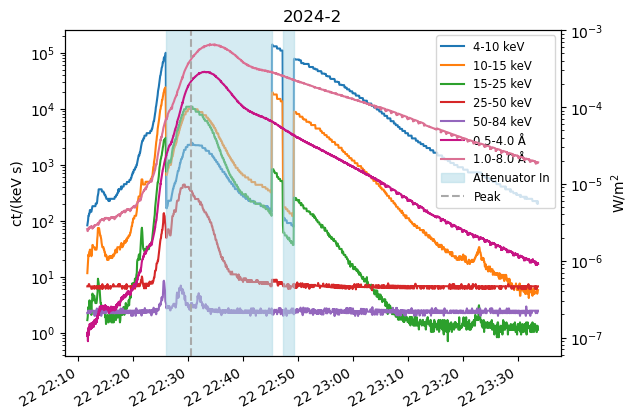

In [110]:
plot_flare('2024-02-22T22:09:36.287', '2024-02-22T23:31:40.296', '2024-02-22 22:30:28.289')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/plot_flare_function_test1.png")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

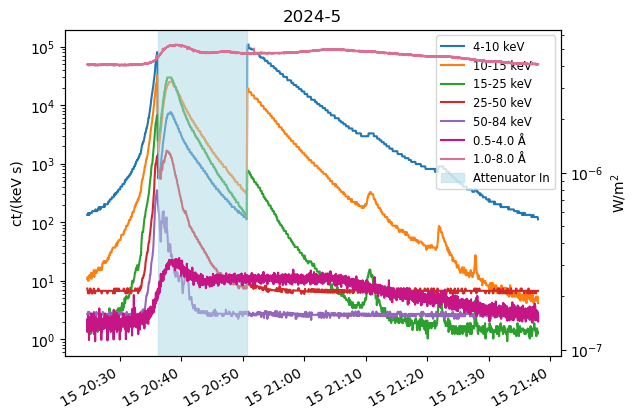

In [113]:
#not visible from Earth but there is a small peak in GOES anyway!
plot_flare('2024-05-15T20:22:27.966', '2024-05-15T21:35:47.874')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/plot_flare_function_not_earth_vis.png")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

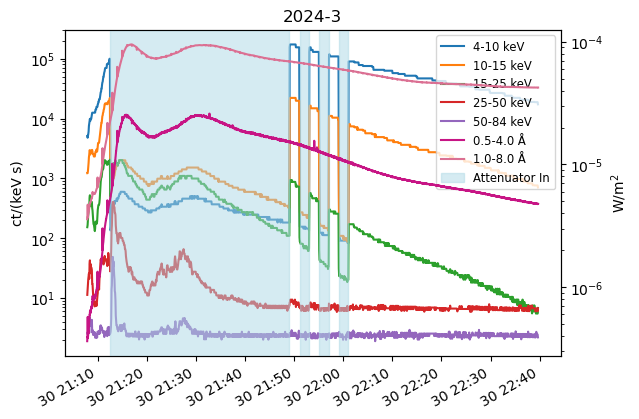

In [114]:
#attenuator comes in and out a lot
plot_flare('2024-03-30T21:02:09.448','2024-03-30T22:33:57.458')
plt.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/plot_flare_function_wacky_attenuator.png")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

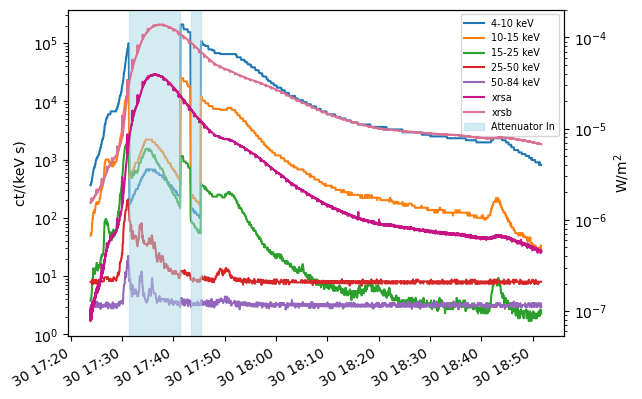

In [91]:
plot_flare('2022-03-30T17:18:15.999','2022-03-30T18:46:12.008')

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

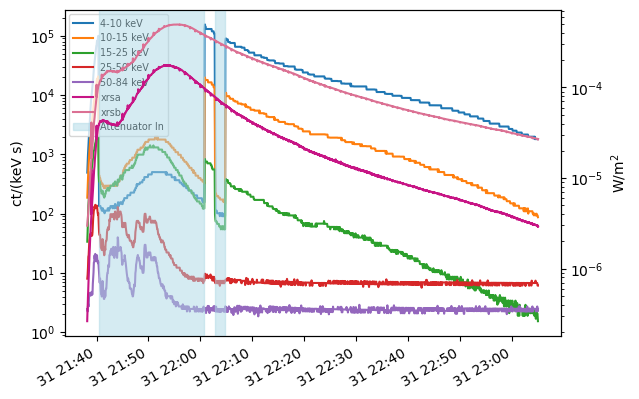

In [92]:
plot_flare('2023-12-31T21:37:55.324','2023-12-31T23:04:47.333')	

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

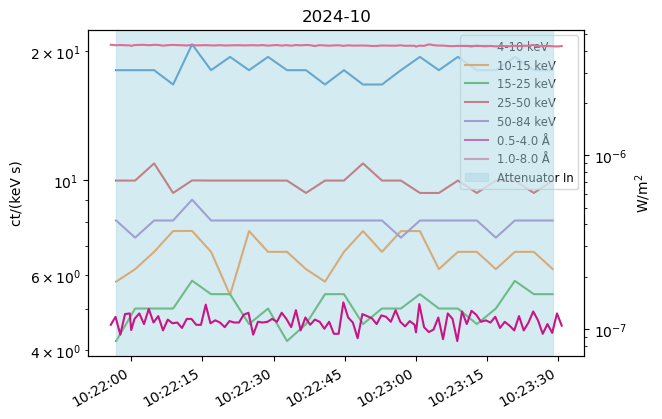

In [112]:
plot_flare('2024-10-09T10:16:31.752', '2024-10-09T10:18:07.753')

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

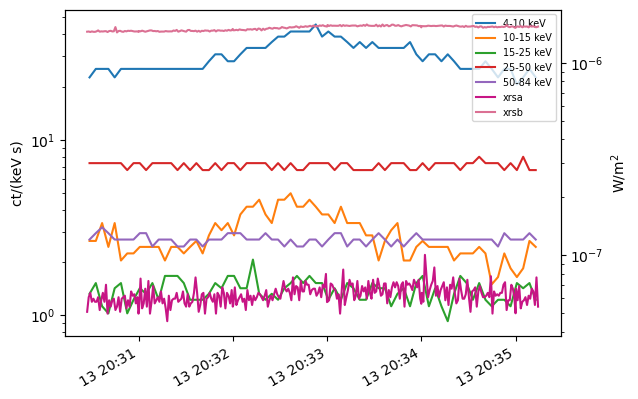

In [94]:
plot_flare('2023-05-13T20:27:31.686','2023-05-13T20:32:19.686')	

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

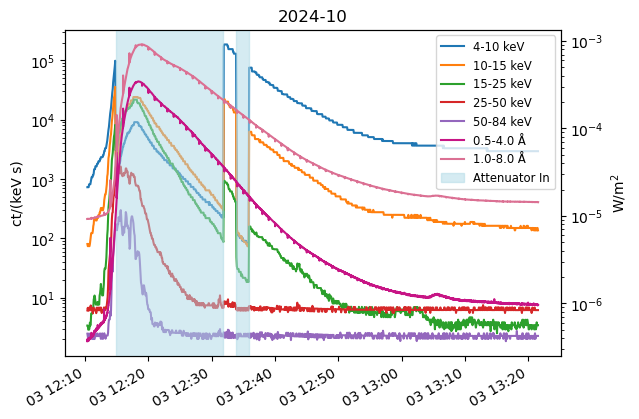

In [115]:
plot_flare('2024-10-03T12:04:29.984','2024-10-03T13:15:41.992')

In [116]:
small_stix_query = Fido.search(a.Time('2024-10-09T10:16:31.752', '2024-10-09T10:18:07.753'), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

small_stix_files = Fido.fetch(small_stix_query)
small_stix_lc = ts.TimeSeries(small_stix_files)
small_stix_df = small_stix_lc.to_dataframe()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [117]:
small_stix_df

,control_index,timedel,triggers,triggers_comp_err,rcr,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,4-10 keV_comp_err,10-15 keV_comp_err,15-25 keV_comp_err,25-50 keV_comp_err,50-84 keV_comp_err
time,,,,,,,,,,,,,,,
2024-10-09 00:00:01.678,0,400.0,3199,73.901962,0,27.975441,2.451499,1.225750,6.073714,2.229304,18.479719,1.224745,1.224745,18.479719,9.246621
2024-10-09 00:00:05.678,0,400.0,3199,73.901962,0,25.307143,2.051254,1.025627,6.073714,2.229304,18.479719,1.224745,1.224745,18.479719,9.246621
2024-10-09 00:00:09.678,0,400.0,2687,73.901962,0,27.972702,2.051054,1.225630,6.713448,2.464501,18.479719,1.224745,1.224745,18.479719,9.246621
2024-10-09 00:00:13.678,0,400.0,3199,73.901962,0,25.307143,2.051254,1.425872,6.073714,2.464743,18.479719,1.224745,1.224745,18.479719,9.246621
2024-10-09 00:00:17.678,0,400.0,2431,73.901962,0,25.303426,2.050953,1.325616,6.072822,2.464381,18.479719,1.224745,1.224745,18.479719,9.246621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-09 23:59:41.578,38,400.0,9727,295.603607,0,25.338783,3.055682,2.078866,7.363693,3.646486,18.479719,1.224745,2.345208,18.479719,9.246621
2024-10-09 23:59:45.578,38,400.0,10751,295.603607,0,25.343754,3.356899,2.279685,7.365137,3.175644,18.479719,2.345208,2.345208,18.479719,9.246621
2024-10-09 23:59:49.578,38,400.0,9727,295.603607,0,25.338783,3.356241,2.479611,6.722500,3.175021,18.479719,2.345208,2.345208,18.479719,9.246621


In [119]:
x = np.where(small_stix_df['rcr']!=0)

In [121]:
small_stix_df.index[x[0]]

DatetimeIndex(['2024-10-09 01:35:57.678000', '2024-10-09 01:36:01.678000',
               '2024-10-09 01:36:05.678000', '2024-10-09 01:36:09.678000',
               '2024-10-09 01:36:13.678000', '2024-10-09 01:36:17.678000',
               '2024-10-09 01:36:21.678000', '2024-10-09 01:36:25.678000',
               '2024-10-09 01:36:29.678000', '2024-10-09 01:36:33.678000',
               ...
               '2024-10-09 13:51:05.678000', '2024-10-09 13:51:09.678000',
               '2024-10-09 13:51:13.678000', '2024-10-09 13:51:17.678000',
               '2024-10-09 13:51:21.678000', '2024-10-09 13:51:25.678000',
               '2024-10-09 13:51:29.678000', '2024-10-09 13:51:33.678000',
               '2024-10-09 13:51:37.678000', '2024-10-09 13:51:41.678000'],
              dtype='datetime64[ns]', name='time', length=11037, freq=None)

In [122]:
starts=[]
for n in range((np.shape(x))[1]):
    # if n==0:
    #     starts.append(att_in_index[0][n])
    if x[0][n]!=1+x[0][n-1]:
        starts.append(x[0][n])

ends=[]
for n in range((np.shape(x))[1]):
    if n==(np.shape(x))[1]-1:
        ends.append(x[0][n])
        break
    elif x[0][n]!=x[0][n+1]-1:
        ends.append(x[0][n])

start_end = list(zip(starts, ends))

In [128]:
start_end

[(np.int64(1439), np.int64(12475))]

In [130]:
small_stix_df.index[starts[0]]

Timestamp('2024-10-09 01:35:57.678000')

In [131]:
small_stix_df.index[ends[0]]

Timestamp('2024-10-09 13:51:41.678000')

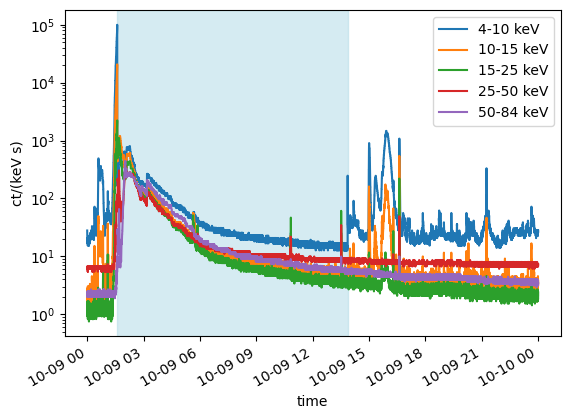

In [132]:
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('ct/(keV s)')
small_stix_df.plot(ax=ax, y='4-10 keV')
small_stix_df.plot(ax=ax, y='10-15 keV')
small_stix_df.plot(ax=ax, y='15-25 keV')
small_stix_df.plot(ax=ax, y='25-50 keV')
small_stix_df.plot(ax=ax, y='50-84 keV')

for pair in start_end:
    plt.axvspan(small_stix_df.index[pair[0]], small_stix_df.index[pair[1]], color='lightblue', alpha=0.5)

#attenuator on continuously from 1:35 to 13:51 after largest flare?

In [147]:
flares.columns

Index(['start_UTC', 'end_UTC', 'peak_UTC', '4-10 keV', '10-15 keV',
       '15-25 keV', '25-50 keV', '50-84 keV', 'bkg 4-10 keV', 'bkg 10-15 keV',
       'bkg 15-25 keV', 'bkg 25-50 keV', 'bkg 50-84 keV',
       'bkg_baseline_4-10 keV', 'hpc_x_solo', 'hpc_y_solo', 'hpc_x_earth',
       'hpc_y_earth', 'visible_from_earth', 'hgs_lon', 'hgs_lat', 'hgc_lon',
       'hgc_lat', 'solo_position_lat', 'solo_position_lon',
       'solo_position_AU_distance', 'GOES_class_time_of_flare',
       'GOES_flux_time_of_flare', 'att_in', 'flare_id', 'sidelobes_ratio',
       'goes_estimated_min_class', 'goes_estimated_max_class',
       'goes_estimated_mean_class', 'goes_estimated_min_flux',
       'goes_estimated_max_flux', 'goes_estimated_mean_flux',
       'error_with_imaging', 'cpd_filename'],
      dtype='str')

In [149]:
start_time_test = '2024-10-03T12:04:29.984'
baseline_410 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 4-10 keV'].values[0]
baseline_1015 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 10-15 keV'].values[0]
baseline_1525 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 15-25 keV'].values[0]
baseline_2550 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 25-50 keV'].values[0]
baseline_5084 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 50-84 keV'].values[0]

In [ ]:
plot_flare('2024-10-03T12:04:29.984','2024-10-03T13:15:41.992')